# Reproducibility: Extension 2 - Reduced Sampling Strategy Check Across Five UE Methods

## Introduction
This extension evaluates how decoding hyperparameters influence uncertainty quality across the five uncertainty estimators used in the project.

Using Mistral-7B on CoQA, we run a reduced set of representative sampling checks for:
- temperature
- top-p
- number of stochastic samples

The greedy white-box methods serve as controls, while the sample-based methods are expected to change most under these settings.


## Experimental Setup
- **Dataset**: CoQA validation split (same dataset as baseline)
- **Model**: `mistralai/Mistral-7B-Instruct-v0.2`
- **UE methods**: Sequence Probability, Perplexity, Token Entropy, Lexical Similarity, Eccentricity
- **Expectation**: the greedy methods should remain stable across settings, while sample-based methods should vary
- **Representative settings**:
  - Temperature: `[1.0]` with default `top-p=0.95`, `n=5`
  - Top-p: `[0.85]` with default `temperature=0.7`, `n=5`
  - Num samples: `[10]` with default `temperature=0.7`, `top-p=0.95`
- **Seed**: 42


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os
from pathlib import Path

# Pick the correct one that actually exists
possible_paths = [
    Path("/content/drive/MyDrive/llms-final/reproducibility_notebooks"),
    Path("/content/drive/MyDrive/llm-new/reproducibility_notebooks"),
    Path("/content/reproducibility_notebooks"),
]

ROOT = None
for p in possible_paths:
    if (p / "src").exists():
        ROOT = p
        break

if ROOT is None:
    raise FileNotFoundError("Could not find project folder with src/. Check your Drive folder name.")

os.chdir(ROOT)
print("Project root:", Path.cwd())
print("src exists:", (Path.cwd() / "src").exists())

Mounted at /content/drive
Project root: /content/drive/MyDrive/llms-final/reproducibility_notebooks
src exists: True


In [ ]:
!python -m pip install -r requirements.txt
!python -m pip install lm_polygraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 25.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.9/267.9 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd()
sys.path.append(str(ROOT / "src"))

from ue_repro_utils import *
print("Imports worked.")

Imports worked.


In [ ]:
import importlib

required_packages = [
    "torch", "transformers", "datasets", "numpy", "pandas",
    "matplotlib", "seaborn", "huggingface_hub", "lm_polygraph"
]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    raise ModuleNotFoundError(
        f"Missing packages: {missing}. Run: pip install -r requirements.txt"
    )
print("Dependency preflight check passed.")


Dependency preflight check passed.


In [ ]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import importlib
from IPython import get_ipython

COLAB_DRIVE_PROJECT = Path("/content/drive/MyDrive/llm-new/reproducibility_notebooks")
COLAB_CONTENT_PROJECT = Path("/content/reproducibility_notebooks")


def resolve_project_root() -> Path:
    probe_paths = []

    # Cursor/VSCode notebooks often expose the active ipynb path here.
    ip = get_ipython()
    if ip is not None:
        nb_file = ip.user_ns.get("__vsc_ipynb_file__")
        if nb_file:
            probe_paths.append(Path(nb_file).resolve().parent)

    workspace_env = os.environ.get("WORKSPACE_PATH")
    if workspace_env:
        probe_paths.append(Path(workspace_env).resolve())

    probe_paths.extend([
        Path.cwd(),
        *Path.cwd().parents,
        COLAB_CONTENT_PROJECT,
        COLAB_DRIVE_PROJECT,
        Path.home() / "llm-new",
        Path.home() / "projects" / "llm-new",
        Path.home() / "reproducibility_notebooks",
        Path("/Users/jeettanksmacbook/llm-new/reproducibility_notebooks"),
    ])

    seen = set()
    for base in probe_paths:
        for candidate in (base, base / "reproducibility_notebooks"):
            try:
                c = candidate.resolve()
            except Exception:
                continue
            if c in seen:
                continue
            seen.add(c)
            if (c / "src").exists():
                return c

    raise FileNotFoundError(
        "Could not locate src/. Run `%cd /content/drive/MyDrive/llm-new/reproducibility_notebooks` "
        "or `%cd /content/reproducibility_notebooks` in a cell, then rerun this cell."
    )


ROOT = resolve_project_root()
OUTPUT_DIR = ROOT
sys.path.append(str(ROOT / "src"))

# Force reload if the module is already loaded
if "ue_repro_utils" in sys.modules:
    importlib.reload(sys.modules["ue_repro_utils"])

# from ue_repro_utils import (
#     EXPANDED_METHODS,
#     get_method_plot_label,
#     set_reproducibility,
#     load_coqa,
#     load_model,
#     sweep_method_prrs,
#     save_json,
# )

from ue_repro_utils import *

sns.set_theme(style="whitegrid")

CFG = {
    "model_id": "mistralai/Mistral-7B-Instruct-v0.2",
    "dataset_name": "coqa",
    "num_samples": 500,
    "max_new_tokens": 50,
    "seed": 42,
    "methods": list(EXPANDED_METHODS),
    "default_temperature": 0.7,
    "default_top_p": 0.95,
    "default_n_samples": 5,
    "temperatures": [1.0],
    "top_p_values": [0.85],
    "n_samples_range": [10],
}

set_reproducibility(CFG["seed"])
print("Configuration loaded.")
print(f"Working directory for outputs: {OUTPUT_DIR}")

Configuration loaded.
Working directory for outputs: /content/drive/MyDrive/llms-final/reproducibility_notebooks


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB


In [ ]:
# Required for gated models if needed
from huggingface_hub import login
login()
# Paste your own token and use.

In [ ]:
%pip install -U "bitsandbytes>=0.46.1" accelerate transformers lm-polygraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 115.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
coqa_data = load_coqa(CFG["num_samples"], seed=CFG["seed"])
print(f"Loaded {len(coqa_data)} CoQA examples.")

model, tokenizer = load_model(
    CFG["model_id"],
    max_new_tokens=CFG["max_new_tokens"],
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/793k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7199 [00:00<?, ? examples/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

  -> using 4-bit quantization
  -> loaded (3.8B params)


In [ ]:
import ue_repro_utils
print(ue_repro_utils.__file__)
print("sweep_method_prrs" in dir(ue_repro_utils))

/content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py
False


In [ ]:
import os, sys
from pathlib import Path

ROOT = Path.cwd()
print("Current folder:", ROOT)

# Make sure src is first in Python path
sys.path.insert(0, str(ROOT / "src"))

import ue_repro_utils
print("Loaded from:", ue_repro_utils.__file__)

Current folder: /content/drive/MyDrive/llms-final/reproducibility_notebooks
Loaded from: /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py


In [ ]:
import importlib
import ue_repro_utils
importlib.reload(ue_repro_utils)

from ue_repro_utils import *
print("sweep_method_prrs loaded:", "sweep_method_prrs" in globals())

sweep_method_prrs loaded: False


In [ ]:
import ue_repro_utils
print("Loaded file:", ue_repro_utils.__file__)

!find /content -name "ue_repro_utils.py" -print

Loaded file: /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py
/content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py
/content/drive/MyDrive/LLMs-Updated/llms-final 2/reproducibility_notebooks/src/ue_repro_utils.py


In [ ]:
import sys, importlib
from pathlib import Path

ROOT = Path.cwd()
SRC = ROOT / "src"

print("ROOT:", ROOT)
print("SRC exists:", SRC.exists())
print("ue_repro_utils exists:", (SRC / "ue_repro_utils.py").exists())

# Put src at the FRONT, not the end
sys.path.insert(0, str(SRC))

# Remove old cached module
if "ue_repro_utils" in sys.modules:
    del sys.modules["ue_repro_utils"]

import ue_repro_utils
importlib.reload(ue_repro_utils)

print("Now loaded from:", ue_repro_utils.__file__)
print("Has sweep_method_prrs:", hasattr(ue_repro_utils, "sweep_method_prrs"))

from ue_repro_utils import *
print("sweep_method_prrs loaded:", "sweep_method_prrs" in globals())

ROOT: /content/drive/MyDrive/llms-final/reproducibility_notebooks
SRC exists: True
ue_repro_utils exists: True
Now loaded from: /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py
Has sweep_method_prrs: False
sweep_method_prrs loaded: False


In [ ]:
import ue_repro_utils

[f for f in dir(ue_repro_utils) if "sweep" in f]

['sweep_eccentricity_prr']

In [ ]:
from pathlib import Path
import shutil, sys, importlib

ROOT = Path("/content/drive/MyDrive/llms-final/reproducibility_notebooks")
SRC_FILE = ROOT / "src" / "ue_repro_utils.py"

# Replace the old Drive file with the uploaded file
shutil.copy("ue_repro_utils.py", SRC_FILE)

print("Updated:", SRC_FILE)

Updated: /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py


In [ ]:
# if "ue_repro_utils" in sys.modules:
#     del sys.modules["ue_repro_utils"]

# sys.path.insert(0, str(ROOT / "src"))

# import ue_repro_utils
# importlib.reload(ue_repro_utils)

# from ue_repro_utils import *

# print("Loaded from:", ue_repro_utils.__file__)
# print("Has sweep_method_prrs:", hasattr(ue_repro_utils, "sweep_method_prrs"))
# print("sweep_method_prrs loaded:", "sweep_method_prrs" in globals())

Loaded from: /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py
Has sweep_method_prrs: True
sweep_method_prrs loaded: True


In [ ]:
import sys, importlib
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/llms-final/reproducibility_notebooks")
sys.path.insert(0, str(ROOT / "src"))

if "ue_repro_utils" in sys.modules:
    del sys.modules["ue_repro_utils"]

import ue_repro_utils
importlib.reload(ue_repro_utils)

from ue_repro_utils import *

print("Loaded from:", ue_repro_utils.__file__)
print("Has sweep_method_prrs:", hasattr(ue_repro_utils, "sweep_method_prrs"))

Loaded from: /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py
Has sweep_method_prrs: True


In [ ]:
from ue_repro_utils import *
sweep_results = sweep_method_prrs(
    model=model,
    tokenizer=tokenizer,
    data=coqa_data,
    method_names=CFG["methods"],
    temperatures=CFG["temperatures"],
    top_p_values=CFG["top_p_values"],
    n_samples_range=CFG["n_samples_range"],
    max_new_tokens=CFG["max_new_tokens"],
    default_temperature=CFG["default_temperature"],
    default_top_p=CFG["default_top_p"],
    default_n_samples=CFG["default_n_samples"],
)

rounded = {
    sweep_name: {
        get_method_plot_label(method): {str(setting): round(value, 3) for setting, value in values.items()}
        for method, values in method_map.items()
    }
    for sweep_name, method_map in sweep_results.items()
}
print(json.dumps(rounded, indent=2))


100%|██████████| 500/500 [08:37<00:00,  1.04s/it]


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 0/500 [00:00<?, ?it/s]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 0/500 [00:00<?, ?it/s]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 0/500 [00:00<?, ?it/s]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

{
  "temperature": {
    "Seq Prob PRR": {
      "1.0": 0.605
    },
    "Perplexity PRR": {
      "1.0": 0.255
    },
    "Token Entropy PRR": {
      "1.0": 0.306
    },
    "Lexical Similarity PRR": {
      "1.0": 0.425
    },
    "Eccentricity PRR": {
      "1.0": 0.464
    }
  },
  "top_p": {
    "Seq Prob PRR": {
      "0.85": 0.605
    },
    "Perplexity PRR": {
      "0.85": 0.255
    },
    "Token Entropy PRR": {
      "0.85": 0.306
    },
    "Lexical Similarity PRR": {
      "0.85": 0.334
    },
    "Eccentricity PRR": {
      "0.85": 0.418
    }
  },
  "n_samples": {
    "Seq Prob PRR": {
      "10": 0.605
    },
    "Perplexity PRR": {
      "10": 0.255
    },
    "Token Entropy PRR": {
      "10": 0.306
    },
    "Lexical Similarity PRR": {
      "10": 0.419
    },
    "Eccentricity PRR": {
      "10": 0.496
    }
  }
}


In [ ]:
payload = {
    "config": CFG,
    "sampling_sweep": {
        sweep_name: {
            method: {str(setting): value for setting, value in values.items()}
            for method, values in method_map.items()
        }
        for sweep_name, method_map in sweep_results.items()
    },
}

save_json(str(OUTPUT_DIR / "extension2_results.json"), payload)
print("Saved: extension2_results.json")

Saved: extension2_results.json


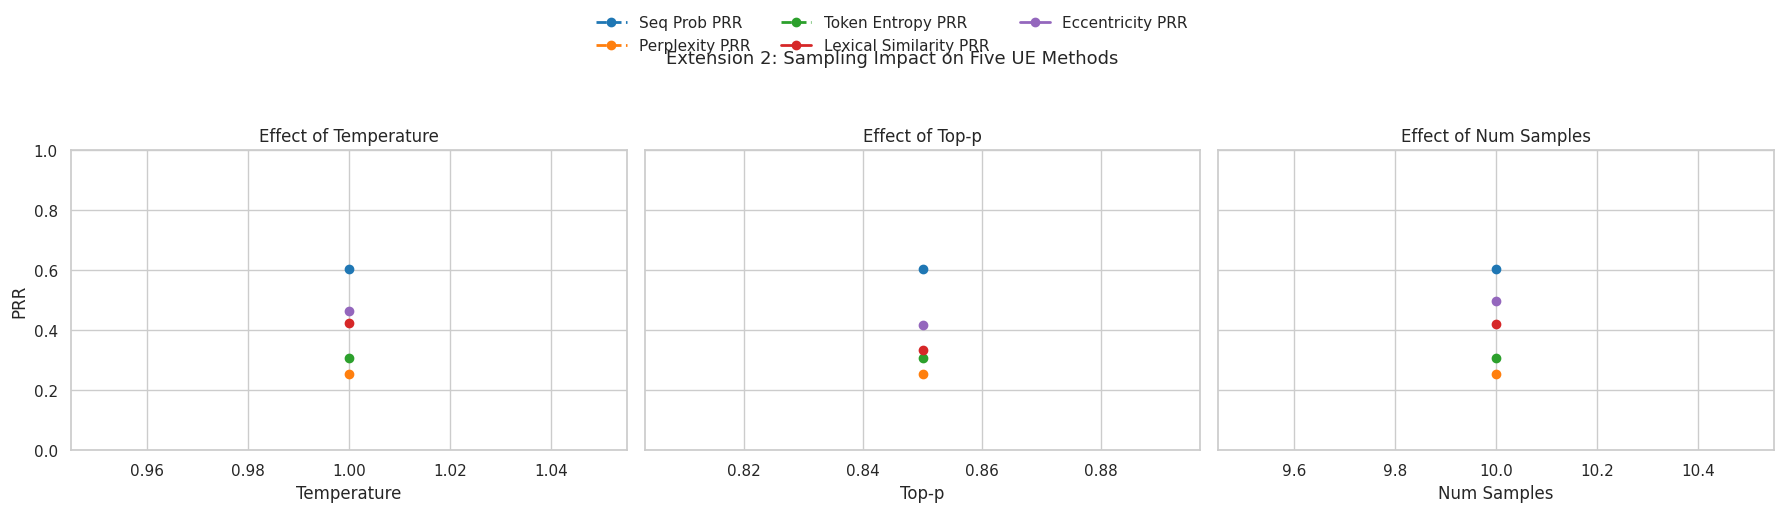

,sweep,method,setting,prr
0,temperature,Seq Prob PRR,1.00,0.6046
1,temperature,Perplexity PRR,1.00,0.2549
2,temperature,Token Entropy PRR,1.00,0.3064
3,temperature,Lexical Similarity PRR,1.00,0.4252
4,temperature,Eccentricity PRR,1.00,0.4645
5,top_p,Seq Prob PRR,0.85,0.6046
6,top_p,Perplexity PRR,0.85,0.2549
7,top_p,Token Entropy PRR,0.85,0.3064
8,top_p,Lexical Similarity PRR,0.85,0.3343
9,top_p,Eccentricity PRR,0.85,0.4179


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)

method_colors = dict(zip(CFG["methods"], sns.color_palette("tab10", len(CFG["methods"]))))
control_methods = {"seq_prob", "perplexity", "token_entropy"}
sweeps = [
    ("temperature", "Temperature", sweep_results["temperature"]),
    ("top_p", "Top-p", sweep_results["top_p"]),
    ("n_samples", "Num Samples", sweep_results["n_samples"]),
]

for ax, (_, xlabel, data) in zip(axes, sweeps):
    for method in CFG["methods"]:
        xs = sorted(data[method].keys())
        ys = [data[method][x] for x in xs]
        linestyle = "--" if method in control_methods else "-"
        ax.plot(
            xs,
            ys,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=method_colors[method],
            label=get_method_plot_label(method),
        )
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1)
    ax.set_title(f"Effect of {xlabel}")

axes[0].set_ylabel("PRR")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.08))
plt.suptitle("Extension 2: Sampling Impact on Five UE Methods", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUTPUT_DIR / "extension2_sampling_sweep.png", dpi=150)
plt.show()

flat_rows = []
for axis_name, method_map in sweep_results.items():
    for method, vals in method_map.items():
        for setting, value in vals.items():
            flat_rows.append(
                {
                    "sweep": axis_name,
                    "method": get_method_plot_label(method),
                    "setting": setting,
                    "prr": round(value, 4),
                }
            )

sweep_df = pd.DataFrame(flat_rows)
display(sweep_df)


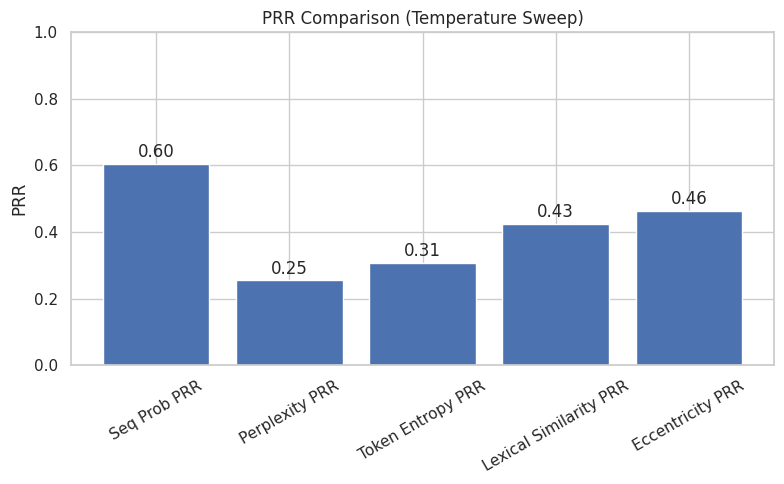

In [ ]:
import matplotlib.pyplot as plt

# Choose which sweep to visualize: "temperature", "top_p", or "n_samples"
sweep_name = "temperature"   # change if needed

data = sweep_results[sweep_name]

methods = []
values = []

for method, vals in data.items():
    # Since there's only one value, just grab it
    setting = list(vals.keys())[0]
    prr = vals[setting]

    methods.append(get_method_plot_label(method))
    values.append(prr)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(methods, values)

plt.ylim(0, 1)
plt.ylabel("PRR")
plt.title(f"PRR Comparison ({sweep_name.capitalize()} Sweep)")
plt.xticks(rotation=30)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center')

plt.tight_layout()
plt.show()

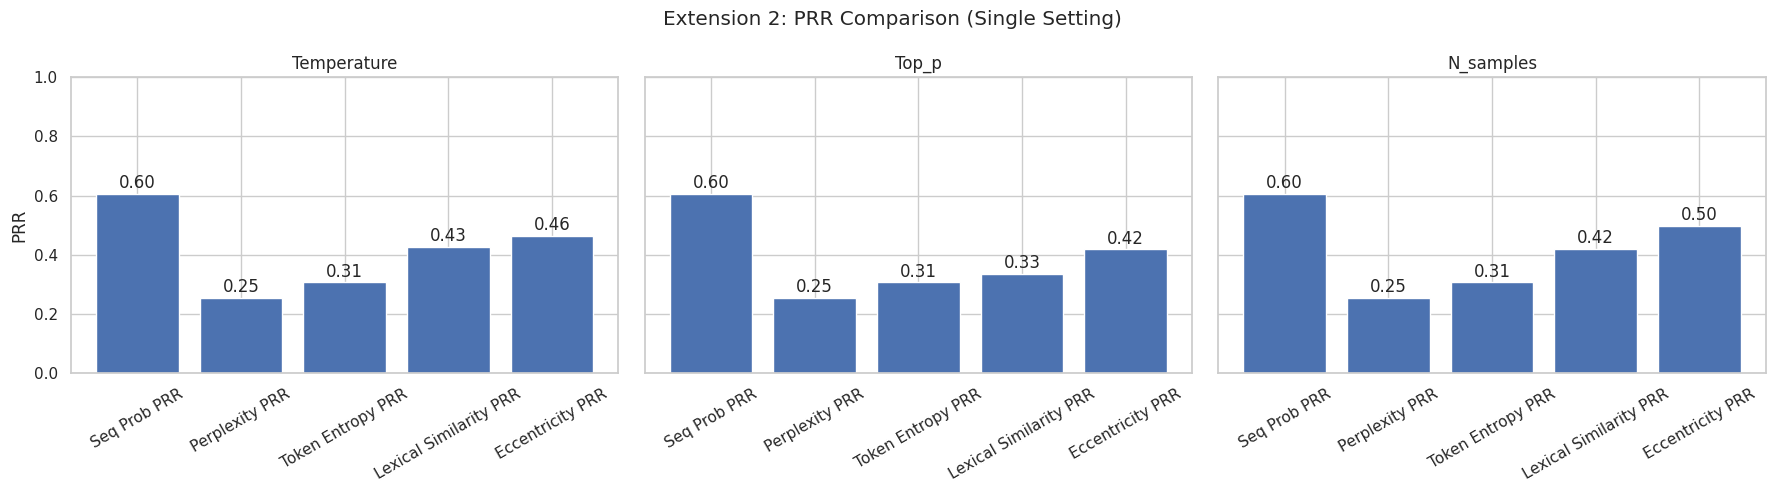

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sweeps = ["temperature", "top_p", "n_samples"]

for ax, sweep_name in zip(axes, sweeps):
    data = sweep_results[sweep_name]

    methods = []
    values = []

    for method, vals in data.items():
        setting = list(vals.keys())[0]
        prr = vals[setting]

        methods.append(get_method_plot_label(method))
        values.append(prr)

    bars = ax.bar(methods, values)
    ax.set_title(sweep_name.capitalize())
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)

    # Labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center')

axes[0].set_ylabel("PRR")

plt.suptitle("Extension 2: PRR Comparison (Single Setting)")
plt.tight_layout()
plt.show()

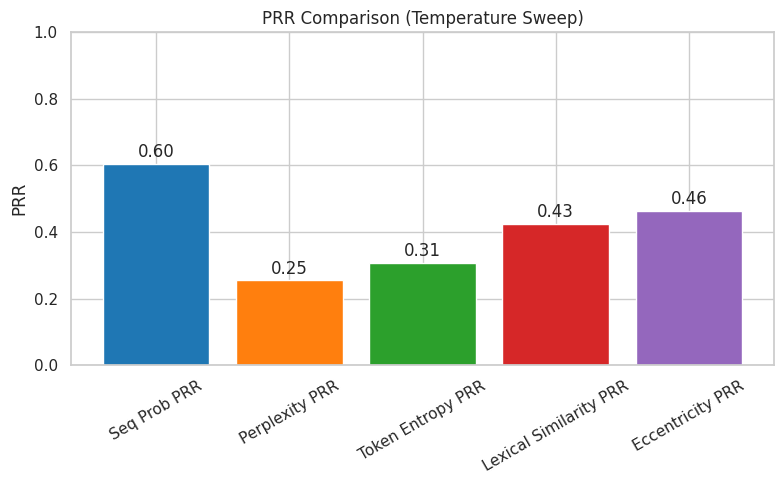

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose sweep
sweep_name = "temperature"
data = sweep_results[sweep_name]

methods = []
values = []

for method, vals in data.items():
    setting = list(vals.keys())[0]
    prr = vals[setting]

    methods.append(get_method_plot_label(method))
    values.append(prr)

# Create color palette
colors = sns.color_palette("tab10", len(methods))

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(methods, values, color=colors)

plt.ylim(0, 1)
plt.ylabel("PRR")
plt.title(f"PRR Comparison ({sweep_name.capitalize()} Sweep)")
plt.xticks(rotation=30)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center')

plt.tight_layout()
plt.show()

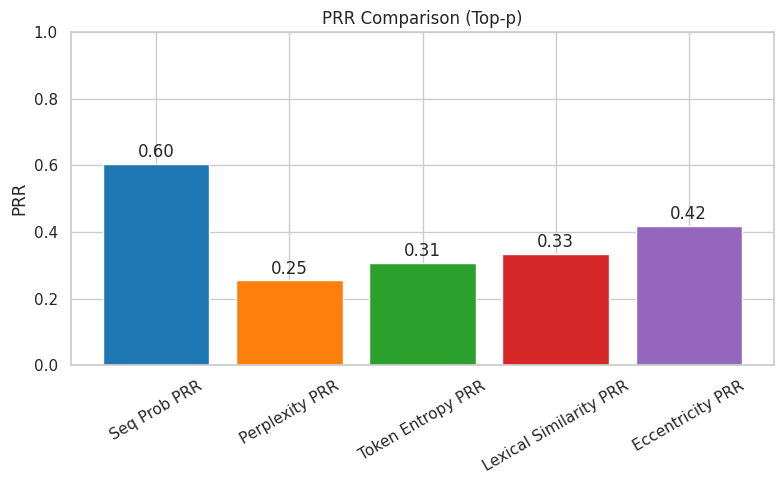

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data = sweep_results["top_p"]

methods = []
values = []

for method, vals in data.items():
    setting = list(vals.keys())[0]
    prr = vals[setting]

    methods.append(get_method_plot_label(method))
    values.append(prr)

colors = sns.color_palette("tab10", len(methods))

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, values, color=colors)

plt.title("PRR Comparison (Top-p)")
plt.ylabel("PRR")
plt.ylim(0, 1)
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center')

plt.tight_layout()
plt.show()

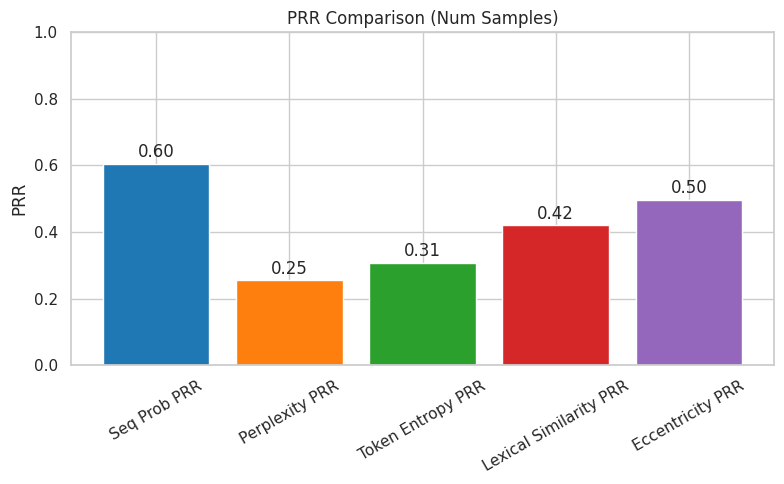

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data = sweep_results["n_samples"]

methods = []
values = []

for method, vals in data.items():
    setting = list(vals.keys())[0]
    prr = vals[setting]

    methods.append(get_method_plot_label(method))
    values.append(prr)

colors = sns.color_palette("tab10", len(methods))

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, values, color=colors)

plt.title("PRR Comparison (Num Samples)")
plt.ylabel("PRR")
plt.ylim(0, 1)
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
payload = {
    "config": CFG,
    "sampling_sweep": {
        sweep_name: {
            method: {str(setting): value for setting, value in values.items()}
            for method, values in method_map.items()
        }
        for sweep_name, method_map in sweep_results.items()
    },
}
save_json(str(OUTPUT_DIR / "extension2_results.json"), payload)
sweep_df.to_csv(OUTPUT_DIR / "extension2_table.csv", index=False)
print("Saved: extension2_results.json, extension2_table.csv, extension2_sampling_sweep.png")


Saved: extension2_results.json, extension2_table.csv, extension2_sampling_sweep.png


In [ ]:
from google.colab import runtime
runtime.unassign()

## Extension Results
Use the sweep figure and table above in the report's **Extension Results** section.

## Resources
- GPU/runtime details are printed in setup cells.

## Code
Add your GitHub repository link in your report's **Code** section.